In [55]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import sys
from tqdm.notebook import tqdm
import torch
import torch.nn as nn

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.3
pandas 3.0.1
sklearn 1.8.0
torch 2.10.0+cu128
cuda:0


# 准备数据

In [56]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(data_home='data')
print(housing.DESCR)
print(housing.data.shape)
print(housing.target.shape)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [57]:
import pprint 

pprint.pprint(housing.data[0:2])
print('-'*50)
pprint.pprint(housing.target[0:2])

array([[ 8.32520000e+00,  4.10000000e+01,  6.98412698e+00,
         1.02380952e+00,  3.22000000e+02,  2.55555556e+00,
         3.78800000e+01, -1.22230000e+02],
       [ 8.30140000e+00,  2.10000000e+01,  6.23813708e+00,
         9.71880492e-01,  2.40100000e+03,  2.10984183e+00,
         3.78600000e+01, -1.22220000e+02]])
--------------------------------------------------
array([4.526, 3.585])


In [58]:
from sklearn.model_selection import train_test_split

x_train_all, x_test, y_train_all, y_test = train_test_split(
    housing.data, housing.target, random_state = 7)
# 分成训练集和测试集
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_all, y_train_all, random_state = 11)
# 将训练集再分成训练集和验证集
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)
print(x_test.shape, y_test.shape)

dataset_maps = {
    "train": [x_train, y_train], # 训练集
    "valid": [x_valid, y_valid], # 验证集
    "test": [x_test, y_test], # 测试集
} #把3个数据集都放到字典中

(11610, 8) (11610,)
(3870, 8) (3870,)
(5160, 8) (5160,)


In [59]:
type(x_train)

numpy.ndarray

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)  # fit返回的是scaler它自己, 里面包含了mean_, var_, std_  
# fit_transform是先fit(获取均值和方差)，然后transform(根据均值和方差标准化)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


# 构建数据集

In [61]:
from torch.utils.data import Dataset

# 自定义数据集, 作用是把原始Numpy数据变成可被DataLoader按批读取的形式
class HousingDataset(Dataset):
    def __init__(self, mode='train'):
        self.x, self.y = dataset_maps[mode]  
        # 取mode对应的[x, y], 拆包分别赋值给self.x, self.y
        self.x = torch.from_numpy(scaler.transform(self.x)).float() 
        # transform将x标准化,(此前做过fit) 
        # 对x.train, x.valid, x.test进行同一种标准化处理
        # from_numpy将NumPy数组转换成PyTorch张量
        # 再将张量的元素转化成float类型 
        self.y = torch.from_numpy(self.y).float().reshape(-1, 1)  
        # y本来是(11610,), reshape(-1, 1)转化为(11610, 1)
        # 处理为多行1列的tensor类型,因为__getitem__切片时需要
            
    def __len__(self): 
        return len(self.x) 
        # 返回数据集的长度, 即第一维的长度
    
    def __getitem__(self, idx): 
        return self.x[idx], self.y[idx]
    # 输入索引idx, 得到第idx个样本. 返回的是一个tuple
    
#train_ds是dataset类型的数据
train_ds = HousingDataset("train")
valid_ds = HousingDataset("valid")
test_ds = HousingDataset("test")

In [62]:
type(train_ds)

__main__.HousingDataset

In [63]:
len(train_ds)

11610

In [64]:
train_ds[:2]
# 看看前两个样本(特征和标签

(tensor([[ 0.8015,  0.2722, -0.1162, -0.2023, -0.5431, -0.0210, -0.5898, -0.0824],
         [-0.2981,  0.3523, -0.1092, -0.2506, -0.0341, -0.0060,  1.0806, -1.0611]]),
 tensor([[3.2260],
         [1.5140]]))

In [65]:
train_ds[0][0]
# 第一个样本的特征

tensor([ 0.8015,  0.2722, -0.1162, -0.2023, -0.5431, -0.0210, -0.5898, -0.0824])

DataLoader

In [66]:
from torch.utils.data import DataLoader

# 放到DataLoader中的train_ds, valid_ds, test_ds都是dataset类型
batch_size = 16
train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_ld = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
test_ld = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# 定义模型

In [67]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 1)
            )
# 回归模型, 输出只需要一个值, 输出层只需要一个神经元
    def forward(self, x):
        # x.shape [batch size, 8]
        logits = self.linear_relu_stack(x)
        # logits.shape [batch size, 1]
        return logits



In [68]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience 
        # 多少个step没有提升min_delta就停止训练
        self.min_delta = min_delta 
        # 最小的提升幅度
        self.best_metric = -1
        self.counter = 0 
        # 计数器, 记录多少个step没有提升
        
    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            # 将当前算子作为最佳算子
            self.counter = 0
        else: 
            self.counter += 1
            # 假如这一步没有更优, 则计数器加一
            
    @property 
    # property装饰器指将方法变成属性
    def early_stop(self):
        return self.counter >= self.patience

In [69]:


@torch.no_grad()
def evaluating(model, dataloader, loss_function):
    loss_list = []
    for datas, labels in dataloader:
        datas = datas.to(device)
        labels = labels.to(device)
        # 前向计算
        logits = model(datas)
        loss = loss_function(logits, labels)         
        # 验证集损失
        loss_list.append(loss.item())
        
    return np.mean(loss_list)

In [70]:
def training(model, train_loader, val_loader, epoch, loss_function,
             optimizer,
             early_stop=None,
             eval_step=500):
    """
    训练函数
    :param model: 模型
    :param train_loader: 训练数据集
    :param val_loader: 验证数据集
    :param epoch: 训练轮数
    :param loss_function: 损失函数
    :param optimizer: 优化器
    :param early_stop: 早停回调函数
    :param eval_step: 每训练多少batch对验证集进行评估
    :return: dict
    """
    record_dict = {
        "train": [],
        "val": []
    }
    # 存储训练集和测试集的损失和准确率
    global_step = 0
    # 记录总步数, 在进度条中使用
    model.train()
    # 进入训练模式
    # 对于一些特定层很重要：
    # Dropout → 在训练阶段才会随机丢弃神经元
    # BatchNorm → 使用 batch 的均值和方差
    with (tqdm(total=epoch * len(train_loader)) as pbar): 
        # with是上下文管理器, 保证进度条结束后自动关闭
        # 进度条一共 len(train_loader)*epoch 步
        for epoch_id in range(epoch): 
            # 训练epoch次
            for data, label in train_loader: 
                # 每次迭代得到一个batch
                # 11610/16=726
                data = data.to(device) 
                # datas尺寸是[batch_size, 8], 转到GPU
                # 每个样本只有8个特征
                label = label.to(device) 
                # labels尺寸是[batch_size], 转到GPU
                optimizer.zero_grad()
                # 梯度清空, PyTorch会累加梯度, 要避免上一batch的梯度影响后面
                logits = model(data)
                # 正向计算, 得到未经过softmax的输出
                loss = loss_function(logits, label)
                # 计算损失
                loss.backward()
                # 梯度回传, loss.backward()会计算梯度, loss对模型参数(权重和偏置)求导
                optimizer.step()
                # 调整优化器, 改变学习率(如果使用了学习率调度器), 更新模型参数和一些其他值
                # 梯度计算并存储在模型参数的 .grad 属性中
                # 优化器使用这些存储的梯度来更新模型参数

                loss = loss.cpu().item()
                # loss这一0维张量转换为数值
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                }) 
                # 记录训练集信息, 每一步的损失, 步数
                
                if global_step % eval_step == 0:
                    model.eval() 
                    # 进入评估模式
                    # Dropout 停用
                    # BatchNorm 使用训练时统计值
                    val_loss = evaluating(model, val_loader, loss_function)
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train() 
                    # 进入训练模式

                    # 3. 早停Early Stop
                    if early_stop is not None:
                        early_stop(-val_loss)
                        # 验证集损失不再下降, 则停止训练
                        if early_stop.early_stop:
                            # 注意之前有property装饰器, 将方法作为属性计算
                            # 属性的值就是方法的返回值
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                global_step += 1 
                # 全局步数加1
                pbar.update(1) 
                # 更新进度条
                pbar.set_postfix({"epoch": epoch_id}) 
                # 设置进度条显示信息
        
    return record_dict

# 对初始学习率和权重衰减进行网格搜索

In [71]:
def plot_learning_curves(record_dict, learning_rate=None, weight_decay=None, sample_step=500):
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    last_step = train_df.index[-1] if len(train_df) > 0 else 0

    # 只绘制 loss
    fig_num = len(train_df.columns)
    if fig_num == 0:
        print("No columns in training record!")
        return

    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    if fig_num == 1:
        axs = [axs]  # 保证 axs 可迭代

    for index, item in enumerate(train_df.columns):
        axs[index].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[index].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[index].grid()
        axs[index].legend()
        axs[index].set_xlabel("Step")
        axs[index].set_xticks(range(0, last_step + 1, max(5000, last_step // 5)))
        axs[index].set_xticklabels(
            [f"{int(x/1000)}k" for x in range(0, last_step + 1, max(5000, last_step // 5))]
        )

    # 设置标题显示当前参数
    title = "Learning Curves"
    if lr is not None and weight_decay is not None:
        title += f" | lr={learning_rate}, weight_decay={weight_decay}"
    fig.suptitle(title, fontsize=14)

    plt.show()


Training with lr=0.001, weight_decay=0


  0%|          | 0/72600 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter serve

Early stop at epoch 46 / global_step 33396


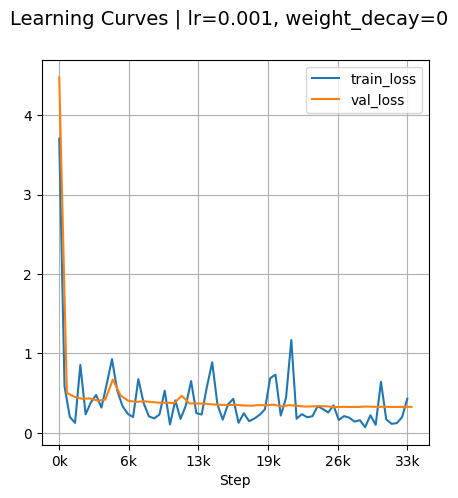


Training with lr=0.001, weight_decay=0.0001


  0%|          | 0/72600 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter serve

Early stop at epoch 98 / global_step 71148


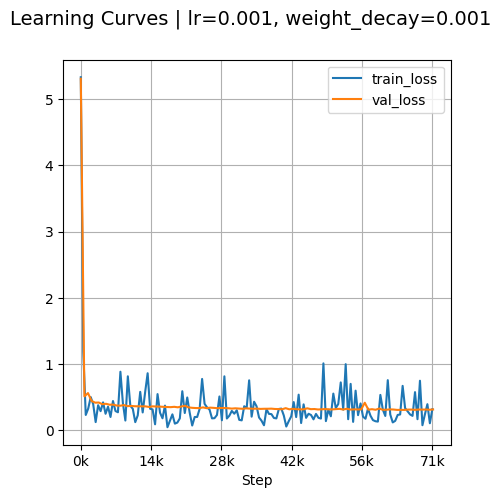


Training with lr=0.01, weight_decay=0


  0%|          | 0/72600 [00:00<?, ?it/s]

Early stop at epoch 9 / global_step 6534


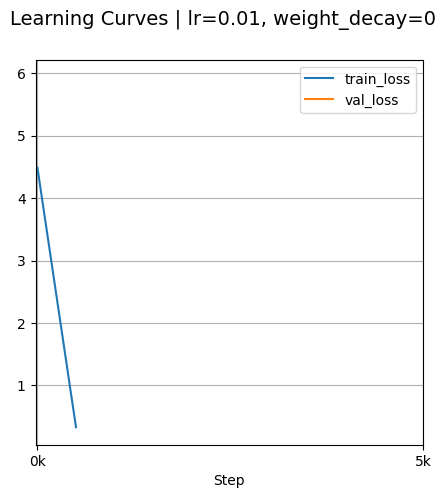


Training with lr=0.01, weight_decay=0.0001


  0%|          | 0/72600 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Early stop at epoch 9 / global_step 6534


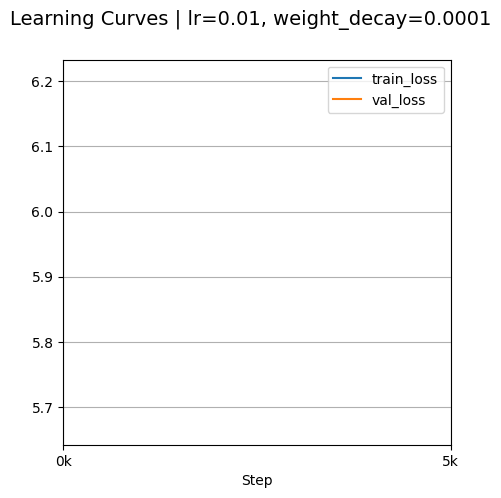


Training with lr=0.01, weight_decay=0.001


  0%|          | 0/72600 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Early stop at epoch 9 / global_step 6534


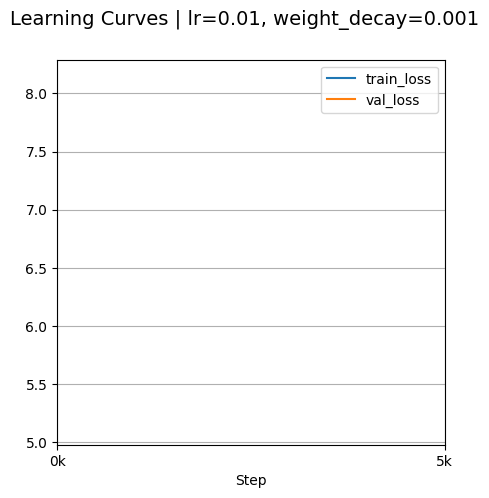


Training with lr=0.002, weight_decay=0


  0%|          | 0/72600 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Early stop at epoch 9 / global_step 6534


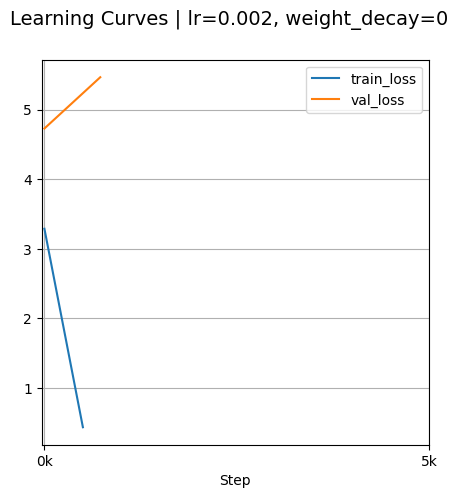


Training with lr=0.002, weight_decay=0.0001


  0%|          | 0/72600 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter serve

Early stop at epoch 75 / global_step 54450


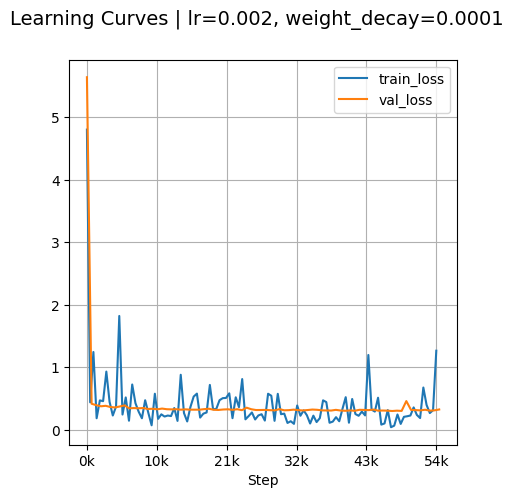


Training with lr=0.002, weight_decay=0.001


  0%|          | 0/72600 [00:00<?, ?it/s]

Early stop at epoch 9 / global_step 6534


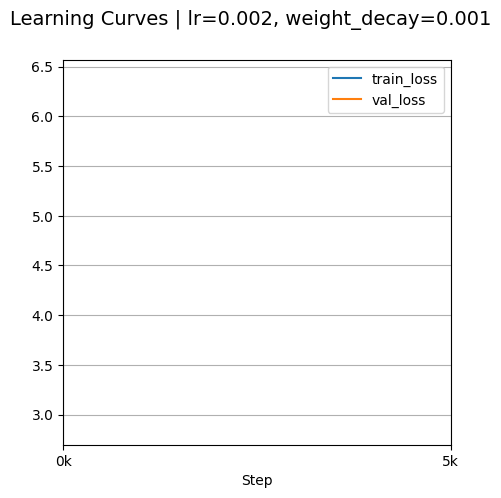


Training with lr=0.02, weight_decay=0


  0%|          | 0/72600 [00:00<?, ?it/s]

Early stop at epoch 9 / global_step 6534


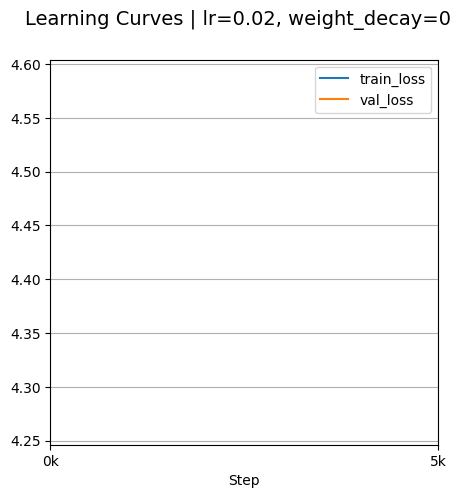


Training with lr=0.02, weight_decay=0.0001


  0%|          | 0/72600 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Early stop at epoch 9 / global_step 6534


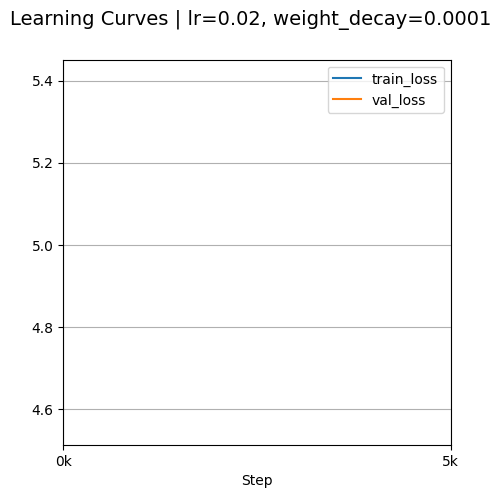


Training with lr=0.02, weight_decay=0.001


  0%|          | 0/72600 [00:00<?, ?it/s]

Early stop at epoch 9 / global_step 6534


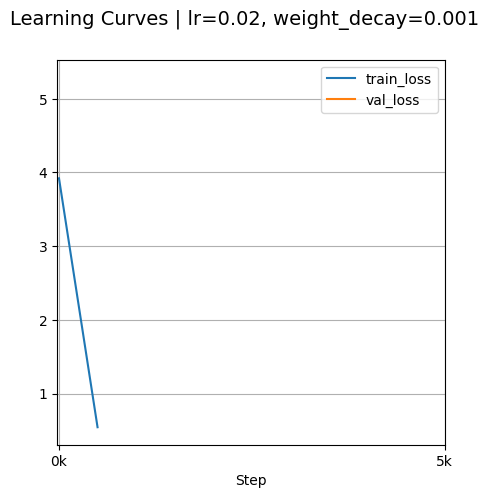


Best parameters: lr=0.001, weight_decay=0.001
Best validation loss: 0.3154


In [72]:
from itertools import product
lr_list = [1e-3, 1e-2, 2e-3, 2e-2]
weight_decay_list = [0, 1e-4, 1e-3]
all_records = {}
val_losses = {}
best_loss = np.inf
best_params = None

for lr, wd in product(lr_list, weight_decay_list):
    print(f"\nTraining with lr={lr}, weight_decay={wd}")
    
    network = NeuralNetwork()
    # 注意每次调整超参需要重新初始化模型, 否则会导致只是在已有的模型参数上测试
    # 假如只初始化一次模型, 在加入了早停的情况下, 第二次便不会训练了
    loss_fct = nn.MSELoss()
    opt = torch.optim.SGD(network.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    early_stop_callback = EarlyStopCallback(patience=10, min_delta=1e-3)
    network = network.to(device)
    epoch_num = 100
    
    record = training(
        network, 
        train_ld, 
        val_ld, 
        epoch_num, 
        loss_fct, 
        opt,
        early_stop=early_stop_callback,
        eval_step=len(train_ld)
    )
    all_records[(lr, wd)] = record
    # 提取 train_loss 和 val_loss 列表
    train_losses = [x['loss'] for x in record['train']]
    val_losses_record = [x['loss'] for x in record['val']]
    
    # 绘图
    plot_learning_curves(record, learning_rate=lr, weight_decay=wd)
    # 最终验证loss
    final_val_loss = val_losses_record[-1] if val_losses_record else float('inf')
    val_losses[(lr, wd)] = final_val_loss
    
    if final_val_loss < best_loss:
        best_loss = final_val_loss
        best_params = (lr, wd)

print("\n==============================")
print(f"Best parameters: lr={best_params[0]}, weight_decay={best_params[1]}")
print(f"Best validation loss: {best_loss:.4f}")